In [3]:
# Re-import required libraries due to kernel reset
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [ ]:
# GridWorld setup
grid_size = (4, 4)
terminal_states = [(0, 0), (3, 3)]
rewards = -0.1 * np.ones(grid_size)
rewards[0, 0] = 1.0
rewards[3, 3] = 1.0
actions = ['U', 'D', 'L', 'R']
action_to_delta = {'U': (-1, 0), 'D': (1, 0), 'L': (0, -1), 'R': (0, 1)} # change in state that occurs when an action is takem
gamma = 0.9 # discount factor
theta = 1e-4 # convergence threshold

In [10]:
def get_transitions(state, action, stochastic=False):
    if state in terminal_states:
        return [(1.0, state)]
    directions = ['U', 'R', 'D', 'L']
    idx = directions.index(action)
    if stochastic:
        probabilities = [0.8, 0.1, 0.0, 0.1] 
    else: # Deterministic: An action from a state has only one specific outcome.
        probabilities = [1.0, 0.0, 0.0, 0.0] 

    transitions = []
    for i, p in enumerate(probabilities):
        real_action = directions[(idx + i) % 4]
        delta = action_to_delta[real_action]
        next_state = (state[0] + delta[0], state[1] + delta[1])
        if 0 <= next_state[0] < grid_size[0] and 0 <= next_state[1] < grid_size[1]:
            transitions.append((p, next_state))
        else:
            transitions.append((p, state))  # wall: stay in place
    return transitions

def q_value_iteration(stochastic=False, greedy_policy=True):
    Q = np.zeros(grid_size + (len(actions),))
    iteration_snapshots = []
    while True:
        delta = 0
        new_Q = np.copy(Q)
        for i in range(grid_size[0]):
            for j in range(grid_size[1]):
                state = (i, j)
                if state in terminal_states:
                    continue
                for a_idx, action in enumerate(actions):
                    q_val = 0
                    for p, s_prime in get_transitions(state, action, stochastic):
                        if greedy_policy:
                            q_val += p * (rewards[s_prime] + gamma * np.max(Q[s_prime]))
                        else: # non-greedy 
                            # i.e non-optimal policy, like epsilon greedy / softmax (doesn't always pick the best action)
                            pi = np.full(len(actions), 1/len(actions))  # uniform random policy, can be changed to epsilon greedy / softmax, user's choice.
                            expected_q = sum(pi[a_idx_] * Q[s_prime][a_idx_] for a_idx_ in range(len(actions)))
                            q_val += p * (rewards[s_prime] + gamma * expected_q)
                    delta = max(delta, abs(q_val - Q[state][a_idx]))
                    new_Q[state][a_idx] = q_val
        Q = new_Q
        iteration_snapshots.append(Q.copy())
        if delta < theta:
            break
    policy = np.full(grid_size, '', dtype=object)
    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            if (i, j) in terminal_states:
                policy[i, j] = 'T'
            else:
                policy[i, j] = actions[np.argmax(Q[i, j])]
    return Q, policy, iteration_snapshots

def q_policy_iteration(stochastic=False, greedy_policy=True):
    Q = np.zeros(grid_size + (len(actions),))
    policy = np.random.choice(actions, size=grid_size)
    iteration_snapshots = []

    stable = False
    while not stable:
        # Policy Evaluation
        while True:
            delta = 0
            new_Q = np.copy(Q)
            for i in range(grid_size[0]):
                for j in range(grid_size[1]):
                    state = (i, j)
                    if state in terminal_states:
                        continue
                    a_idx = actions.index(policy[state])
                    q_val = 0
                    for p, s_prime in get_transitions(state, policy[state], stochastic):
                        if s_prime in terminal_states:
                            q_val += p * (rewards[s_prime])
                        else:
                            if greedy_policy:
                                next_a_idx = actions.index(policy[s_prime])
                                q_val += p * (rewards[s_prime] + gamma * Q[s_prime][next_a_idx])
                            else:
                                pi = np.full(len(actions), 1/len(actions))  # uniform policy π(a'|s')
                                expected_q = sum(pi[a_idx_] * Q[s_prime][a_idx_] for a_idx_ in range(len(actions)))
                                q_val += p * (rewards[s_prime] + gamma * expected_q) 
                    delta = max(delta, abs(q_val - Q[state][a_idx]))
                    new_Q[state][a_idx] = q_val
            Q = new_Q
            iteration_snapshots.append(Q.copy())
            if delta < theta:
                break
            
        # Policy Improvement
        stable = True
        for i in range(grid_size[0]):
            for j in range(grid_size[1]):
                if (i, j) in terminal_states:
                    policy[i, j] = 'T'
                    continue
                best_action = actions[np.argmax(Q[i, j])]
                if best_action != policy[i, j]:
                    policy[i, j] = best_action
                    stable = False
    return Q, policy, iteration_snapshots

In [11]:
def plot_policy_grid(Q, policy, title):
    fig, ax = plt.subplots(figsize=(6, 6))
    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            ax.add_patch(patches.Rectangle((j, grid_size[0]-1-i), 1, 1, fill=False))
            val = np.max(Q[i, j])
            ax.text(j + 0.5, grid_size[0]-1-i + 0.6, f"{val:.2f}", ha='center', fontsize=8)
            ax.text(j + 0.5, grid_size[0]-1-i + 0.25, policy[i, j], ha='center', fontsize=12, fontweight='bold')
    ax.set_xlim(0, grid_size[1])
    ax.set_ylim(0, grid_size[0])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_q_snapshots(snapshots, title_prefix):
    for i, Q in enumerate(snapshots[::max(1, len(snapshots)//5)]):
        V = np.max(Q, axis=-1)
        fig, ax = plt.subplots()
        c = ax.imshow(V, cmap='coolwarm', origin='upper')
        ax.set_title(f"{title_prefix} - Iteration {i+1}")
        fig.colorbar(c)
        plt.show()

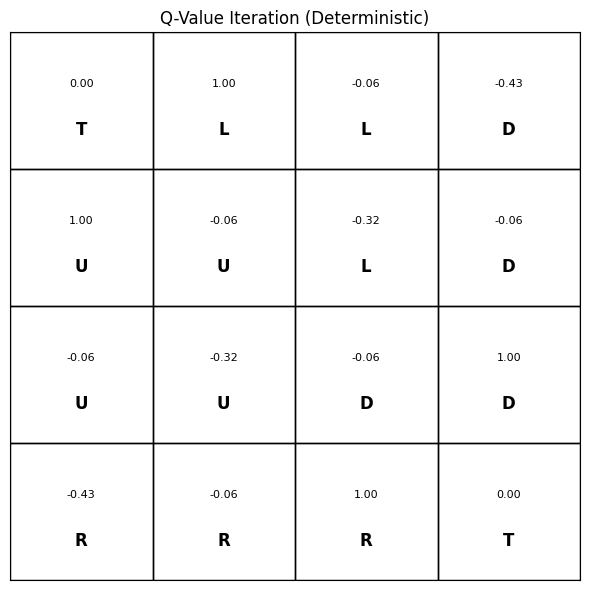

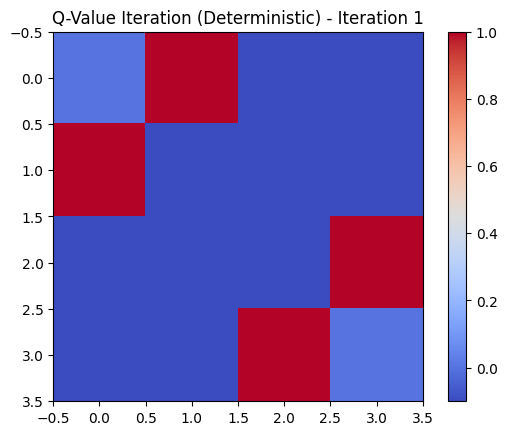

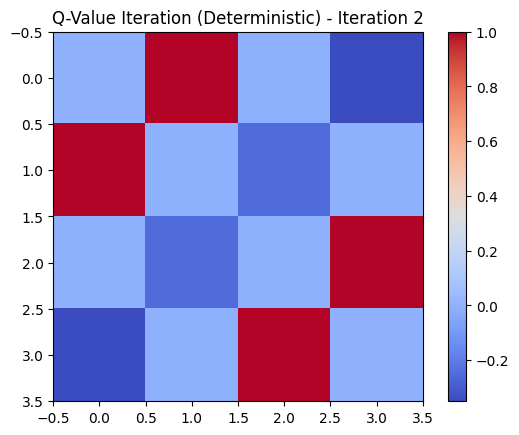

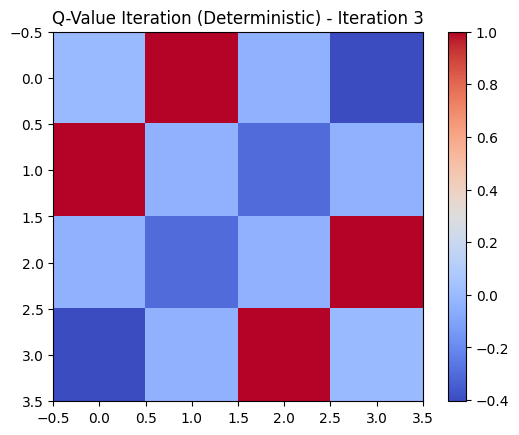

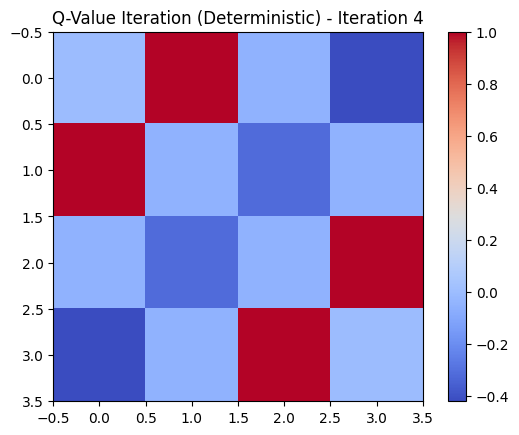

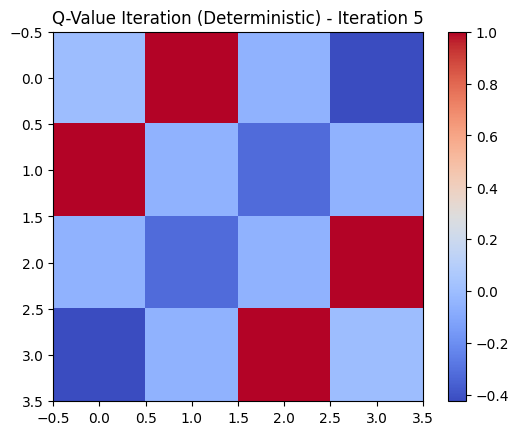

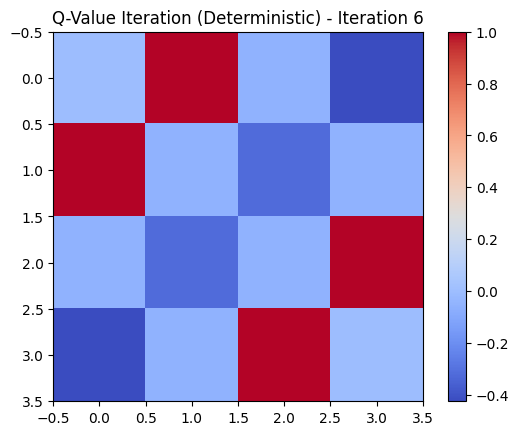

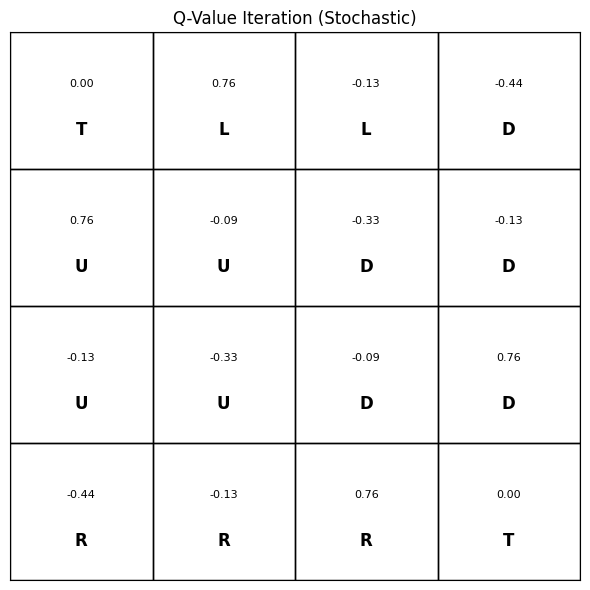

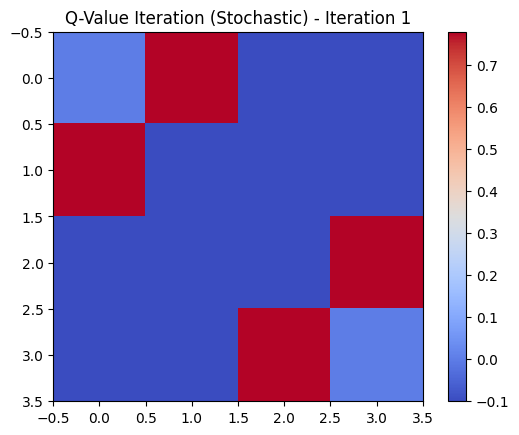

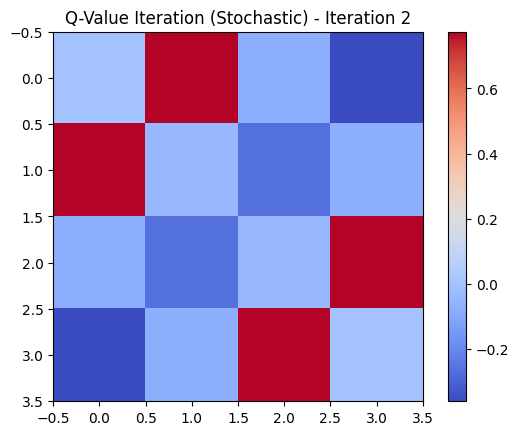

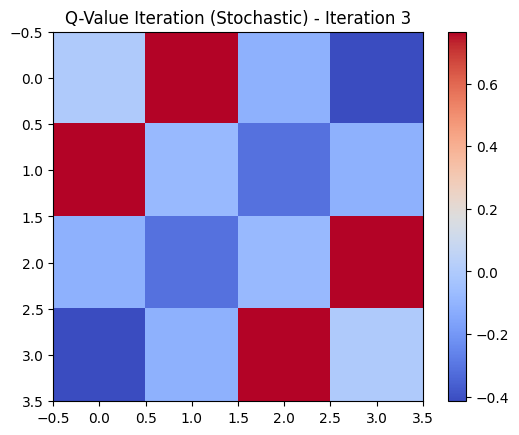

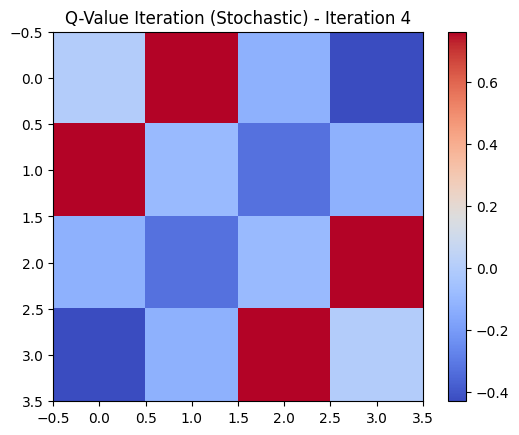

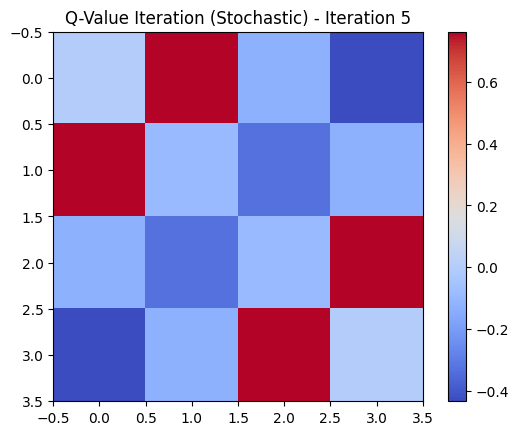

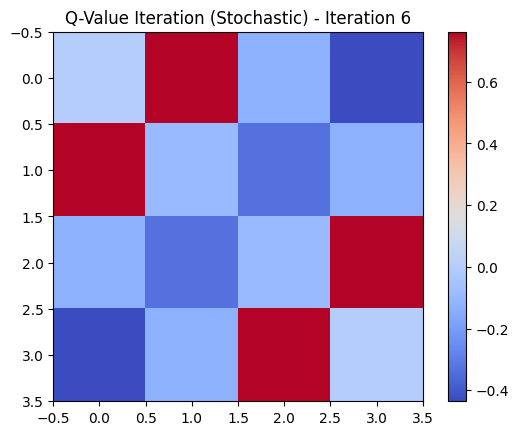

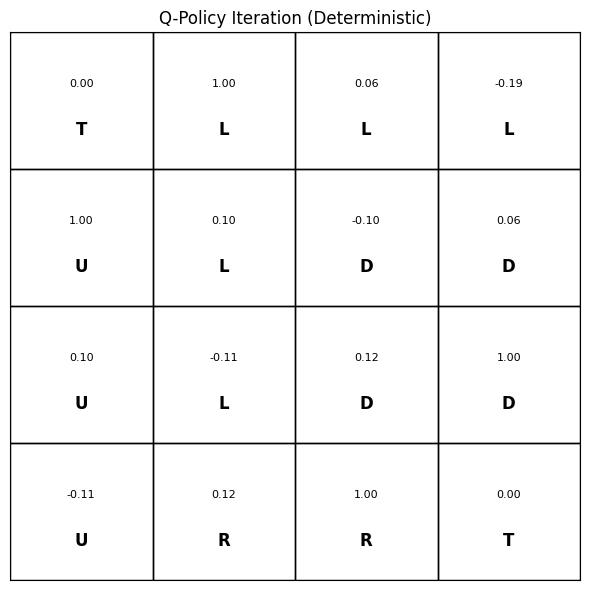

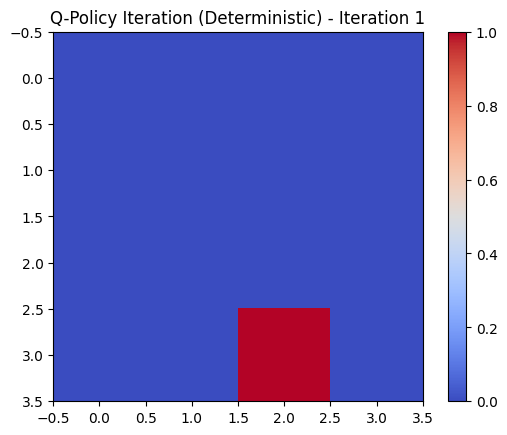

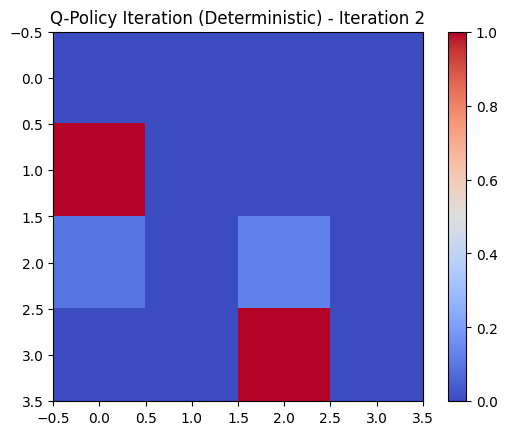

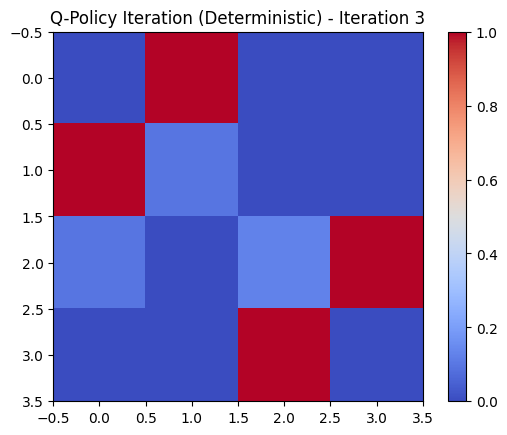

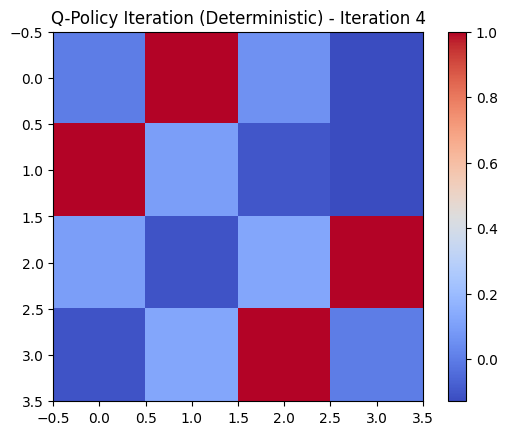

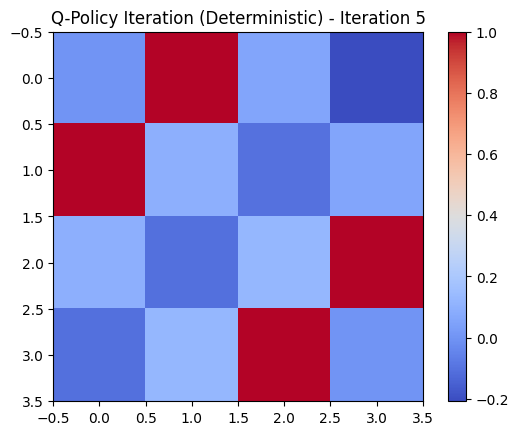

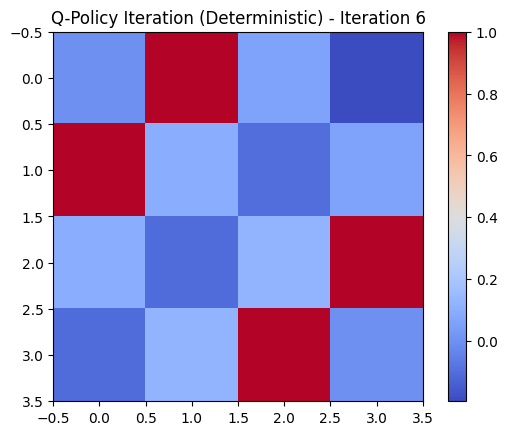

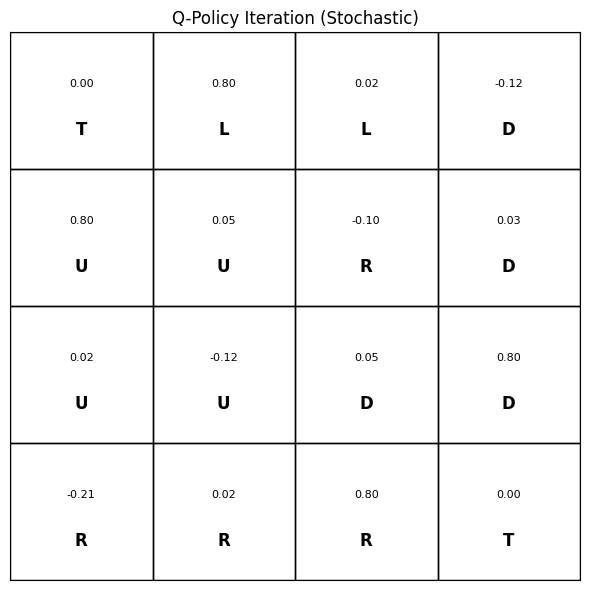

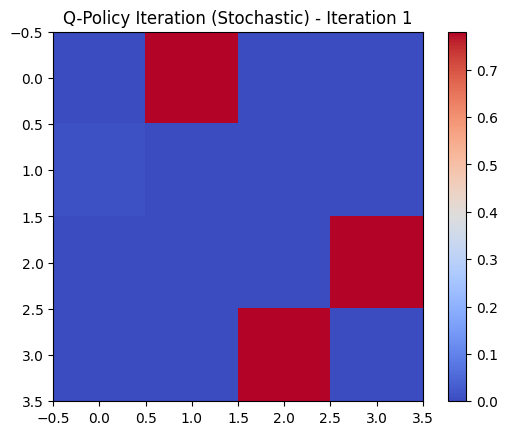

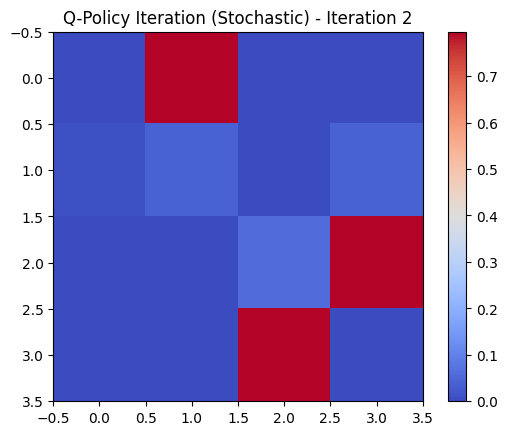

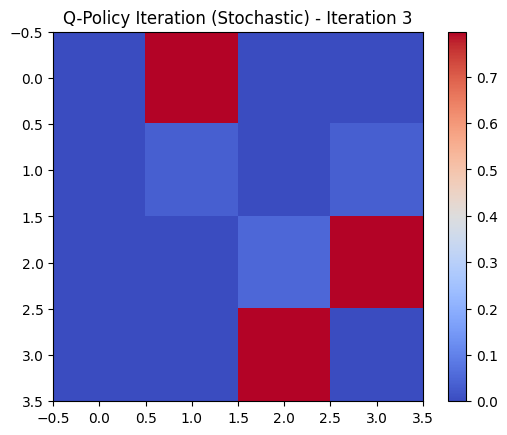

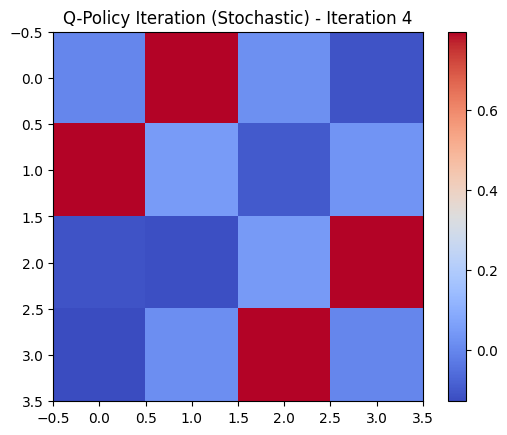

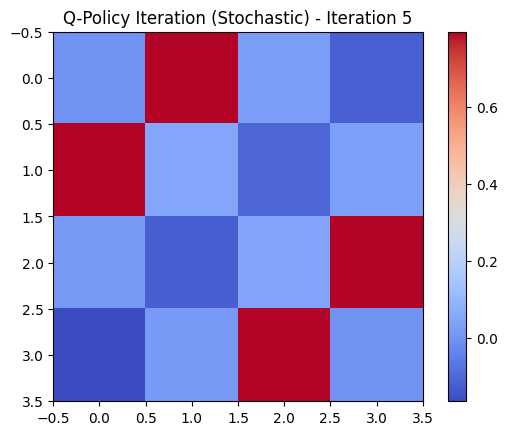

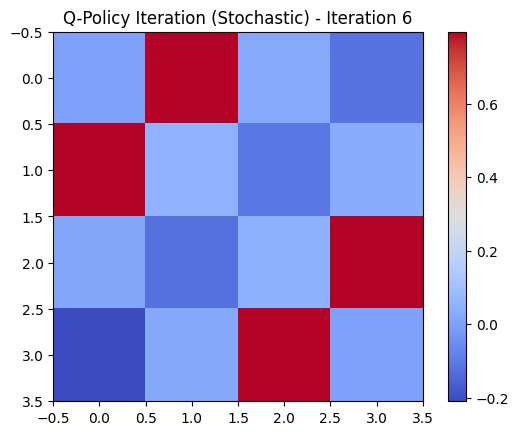

In [12]:
# Run and plot
Q_vi_det, policy_vi_det, snap_vi_det = q_value_iteration(stochastic=False, greedy_policy=False)
Q_vi_sto, policy_vi_sto, snap_vi_sto = q_value_iteration(stochastic=True, greedy_policy=False)

Q_pi_det, policy_pi_det, snap_pi_det = q_policy_iteration(stochastic=False, greedy_policy=False)
Q_pi_sto, policy_pi_sto, snap_pi_sto = q_policy_iteration(stochastic=True, greedy_policy=False)

plot_policy_grid(Q_vi_det, policy_vi_det, "Q-Value Iteration (Deterministic)")
plot_q_snapshots(snap_vi_det, "Q-Value Iteration (Deterministic)")

plot_policy_grid(Q_vi_sto, policy_vi_sto, "Q-Value Iteration (Stochastic)")
plot_q_snapshots(snap_vi_sto, "Q-Value Iteration (Stochastic)")

plot_policy_grid(Q_pi_det, policy_pi_det, "Q-Policy Iteration (Deterministic)")
plot_q_snapshots(snap_pi_det, "Q-Policy Iteration (Deterministic)")

plot_policy_grid(Q_pi_sto, policy_pi_sto, "Q-Policy Iteration (Stochastic)")
plot_q_snapshots(snap_pi_sto, "Q-Policy Iteration (Stochastic)")